scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---

--- Step 1: Loading and Annotating pbmc3k Data ---


/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.

--- Step 3: Training Optimal Model (RBF SVM, Balanced) ---
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 1000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---

Optimal model trained!

  RUNNING PREDICTION WITH THRESHOLD: 0.0
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing f

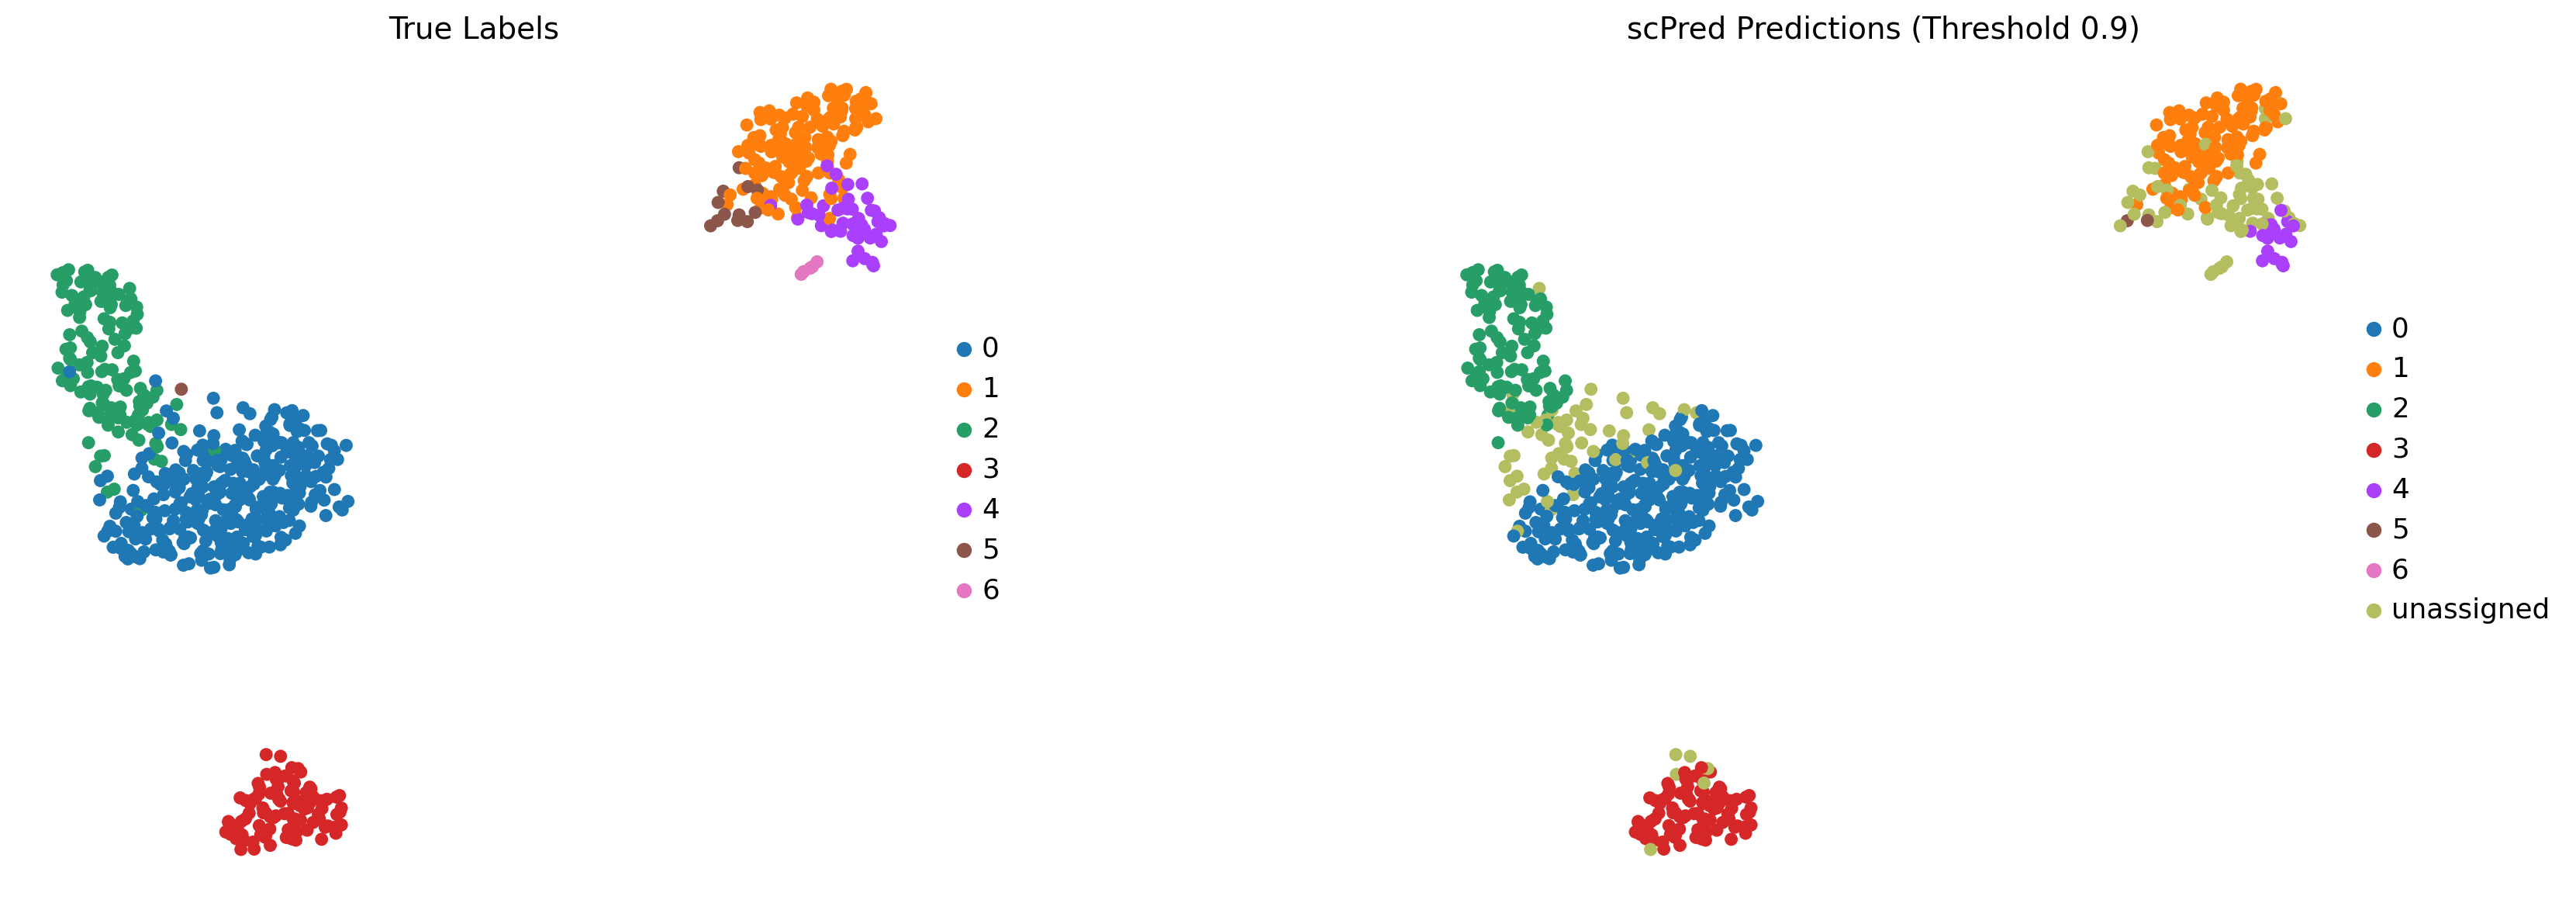


--- UMAP: Misclassified & Unassigned Cells ---


KeyError: False

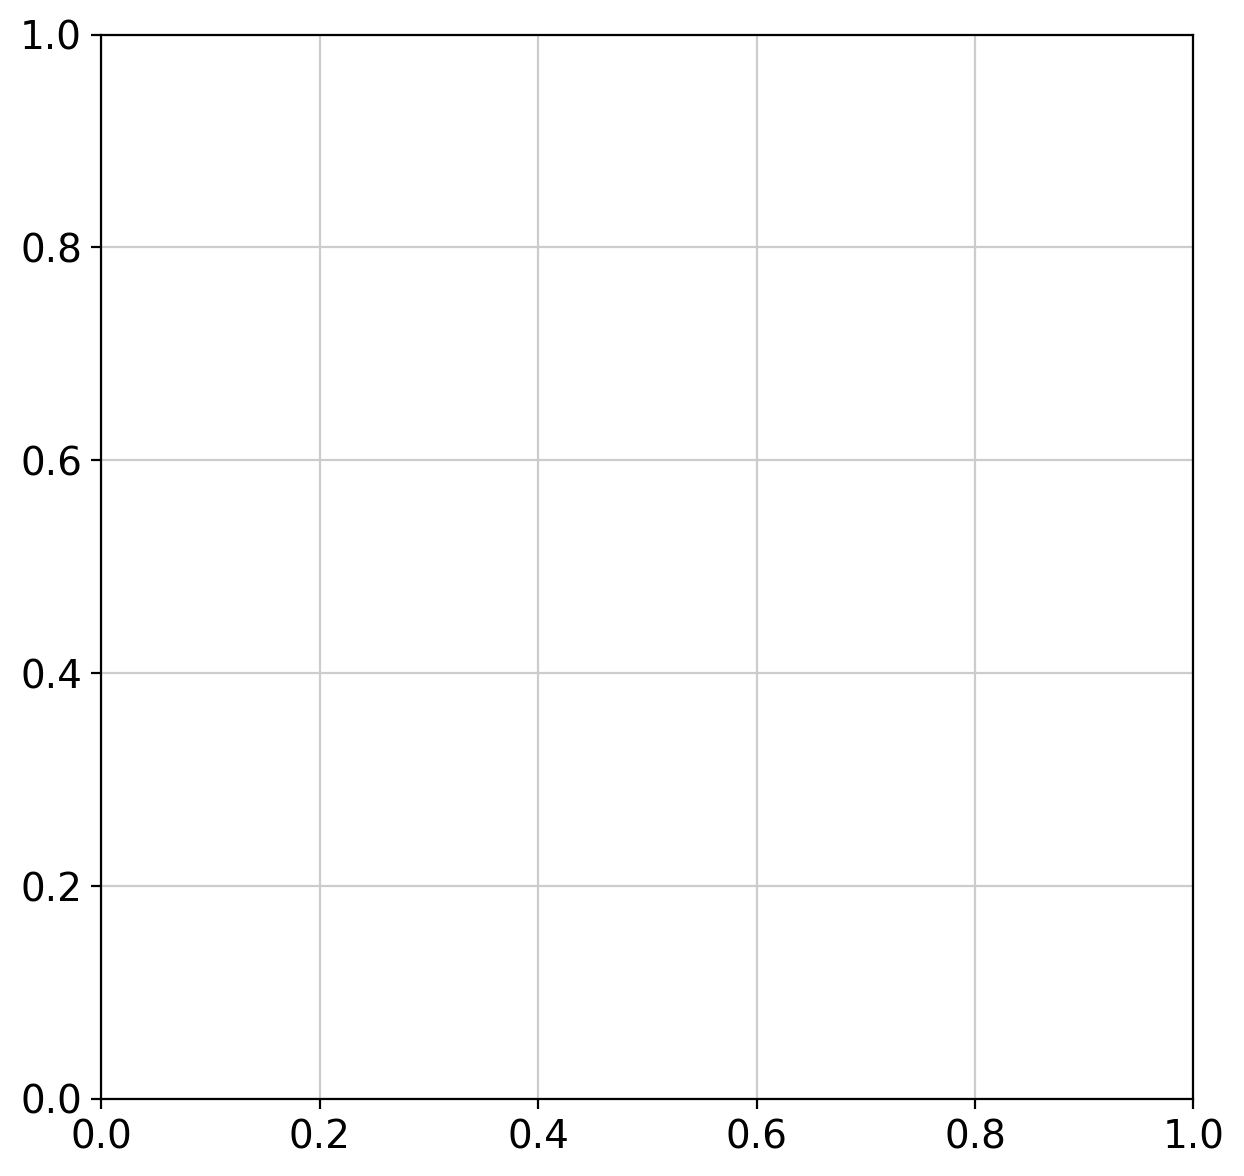

In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_final import ScPredModel
from scpred_py_final import _analysis_utils

# --- Environment Setup ---
print("--- Setting up environment for reproducibility ---")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sc.settings.set_figure_params(dpi=100, facecolor='white', figsize=(7, 7))

# --- 1. Data Loading and Annotation ---
print("\n--- Step 1: Loading and Annotating pbmc3k Data ---")
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
# Generate 'cell_type' labels
temp_adata_for_labels = adata.copy()
sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
sc.pp.log1p(temp_adata_for_labels)
sc.pp.highly_variable_genes(temp_adata_for_labels)
sc.pp.scale(temp_adata_for_labels, max_value=10)
sc.tl.pca(temp_adata_for_labels, random_state=RANDOM_STATE)
sc.pp.neighbors(temp_adata_for_labels, random_state=RANDOM_STATE)
sc.tl.louvain(temp_adata_for_labels, random_state=RANDOM_STATE, key_added='cell_type')
adata.obs['cell_type'] = temp_adata_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category')
print("Data loading and labeling complete.")

# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")

# --- 3. Training the Optimal scPred Model for pbmc3k ---
print("\n--- Step 3: Training Optimal Model (RBF SVM, Balanced) ---")
scpred_model = ScPredModel()

# Train using the best parameters identified in the comparative analysis
scpred_model.train(
    ref_adata=ref_adata_raw,
    cell_type_key='cell_type',
    n_components=30,
    hvg_n_top_genes=1000,
    svm_kernel='rbf',
    svm_c=1.0,
    svm_random_state=RANDOM_STATE,
    svm_class_weight='balanced'
)
print("\nOptimal model trained!")

# --- 4. Prediction and Evaluation at Different Thresholds ---

def run_prediction_and_eval(model, query_data, threshold):
    """Helper function to run prediction and print a summary."""
    print("\n" + "="*50)
    print(f"  RUNNING PREDICTION WITH THRESHOLD: {threshold}")
    print("="*50)

    query_pred = model.predict(query_data.copy(), threshold=threshold)
    print("\nPredicted label distribution:")
    print(query_pred.obs['scpred_prediction'].value_counts(dropna=False))

    prob_cols = [col for col in query_pred.obs.columns if col.startswith('scpred_prob_')]
    y_pred_probs_df = query_pred.obs[prob_cols].copy() if prob_cols else None
    
    _analysis_utils.evaluate_and_report_metrics(
        true_labels=query_pred.obs['cell_type'],
        predicted_labels=query_pred.obs['scpred_prediction'],
        classifier_classes=model.classifier_.classes_,
        y_pred_probs=y_pred_probs_df
    )
    return query_pred

# Run with threshold=0.0 (full coverage)
query_pred_t0 = run_prediction_and_eval(scpred_model, query_adata_raw, threshold=0.0)

# Run with threshold=0.9 (high confidence)
query_pred_t9 = run_prediction_and_eval(scpred_model, query_adata_raw, threshold=0.9)

# --- 5. Final Visualizations for the Report ---
print("\n--- Step 5: Final UMAP Visualizations ---")
sc.pp.neighbors(query_pred_t9, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE)
sc.tl.umap(query_pred_t9, random_state=RANDOM_STATE)

print("\n--- UMAP: True Labels vs. High-Confidence Predictions (Threshold=0.9) ---")
sc.pl.umap(
    query_pred_t9,
    color=['cell_type', 'scpred_prediction'],
    title=['True Labels', f'scPred Predictions (Threshold {0.9})'],
    frameon=False, wspace=0.4
)

print("\n--- UMAP: Misclassified & Unassigned Cells ---")
query_pred_t9.obs['misclassified'] = (query_pred_t9.obs['cell_type'].astype(str) != query_pred_t9.obs['scpred_prediction'].astype(str)).astype('category')
sc.pl.umap(
    query_pred_t9,
    color='misclassified',
    palette={'False': 'lightgray', 'True': 'red'},
    title='Misclassified & Unassigned Cells (in Red)',
    frameon=False
)

print("\n--- Analysis Complete ---")

scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility and file management ---
Ensuring directories exist: ../models and ../data/preprocessed
Directories ensured.

--- Step 1: Loading and Annotating Data ---
Initial raw AnnData object shape: (2700, 32738)
Initial raw AnnData .obs keys: []
Initial raw AnnData .var keys: ['gene_ids']

Generating temporary cell type labels via Louvain clustering...


/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Full dataset (raw counts + Louvain labels) shape: (2700, 32738)
Full dataset .obs keys after labeling: ['cell_type']
Cell type distribution (all data):
 cell_type
0    815
1    467
2    459
3    371
4    345
5    184
6     45
7     14
Name: count, dtype: int64

--- Step 2: Splitting Data (Stratified) ---
Reference data (raw + labels) shape: (1890, 32738)
Query data (raw + labels) shape: (810, 32738)

Reference cell type distribution:
 cell_type
0    570
1    327
2    321
3    260
4    241
5    129
6     32
7     10
Name: count, dtype: int64

Query cell type distribution:
 cell_type
0    245
1    140
2    138
3    111
4    104
5     55
6     13
7      4
Name: count, dtype: int64

--- Class Imbalance Analysis ---
Reference data class imbalance (proportion):
 cell_type
0    0.301587
1    0.173016
2    0.169841
3    0.137566
4    0.127513
5    0.068254
6    0.016931
7    0.005291
Name: proportion, dtype: float64
Query data class imbalance (proportion):
 cell_type
0    0.302469
1    0.17284

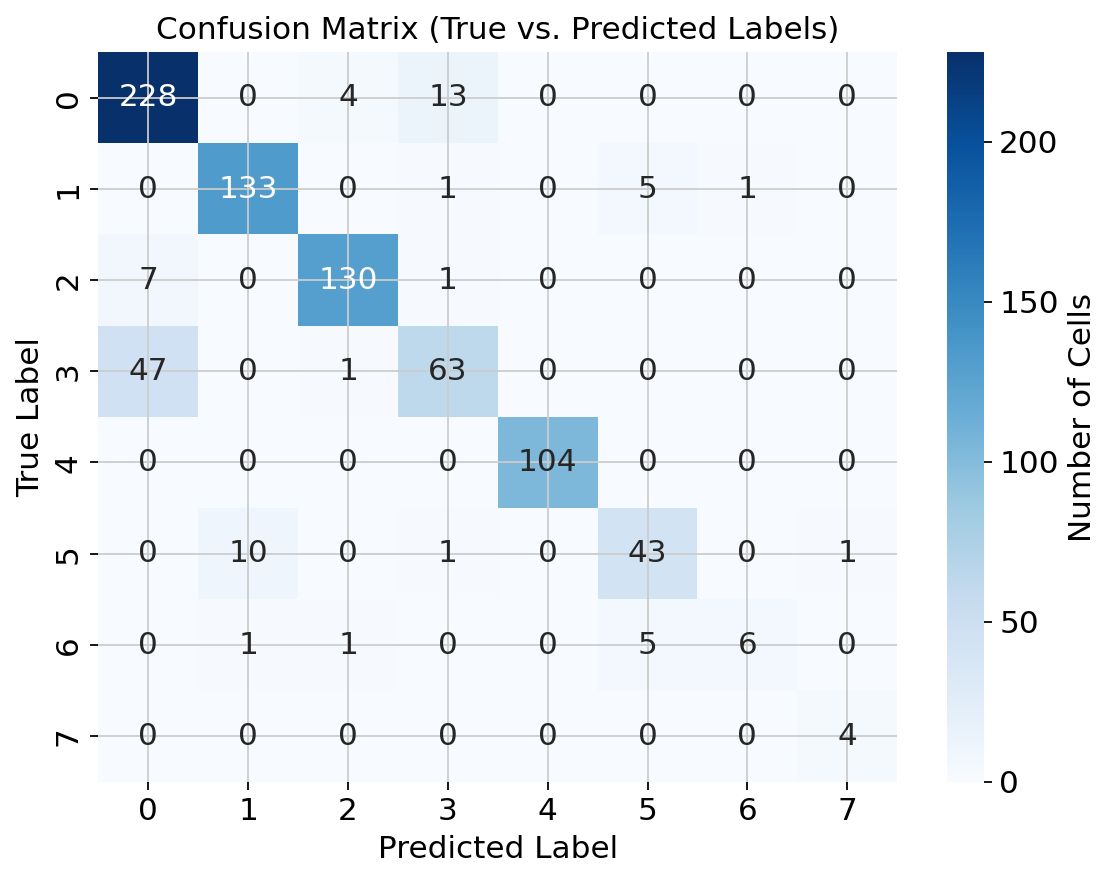


--- Per-Class ROC AUC (One-vs-Rest) ---


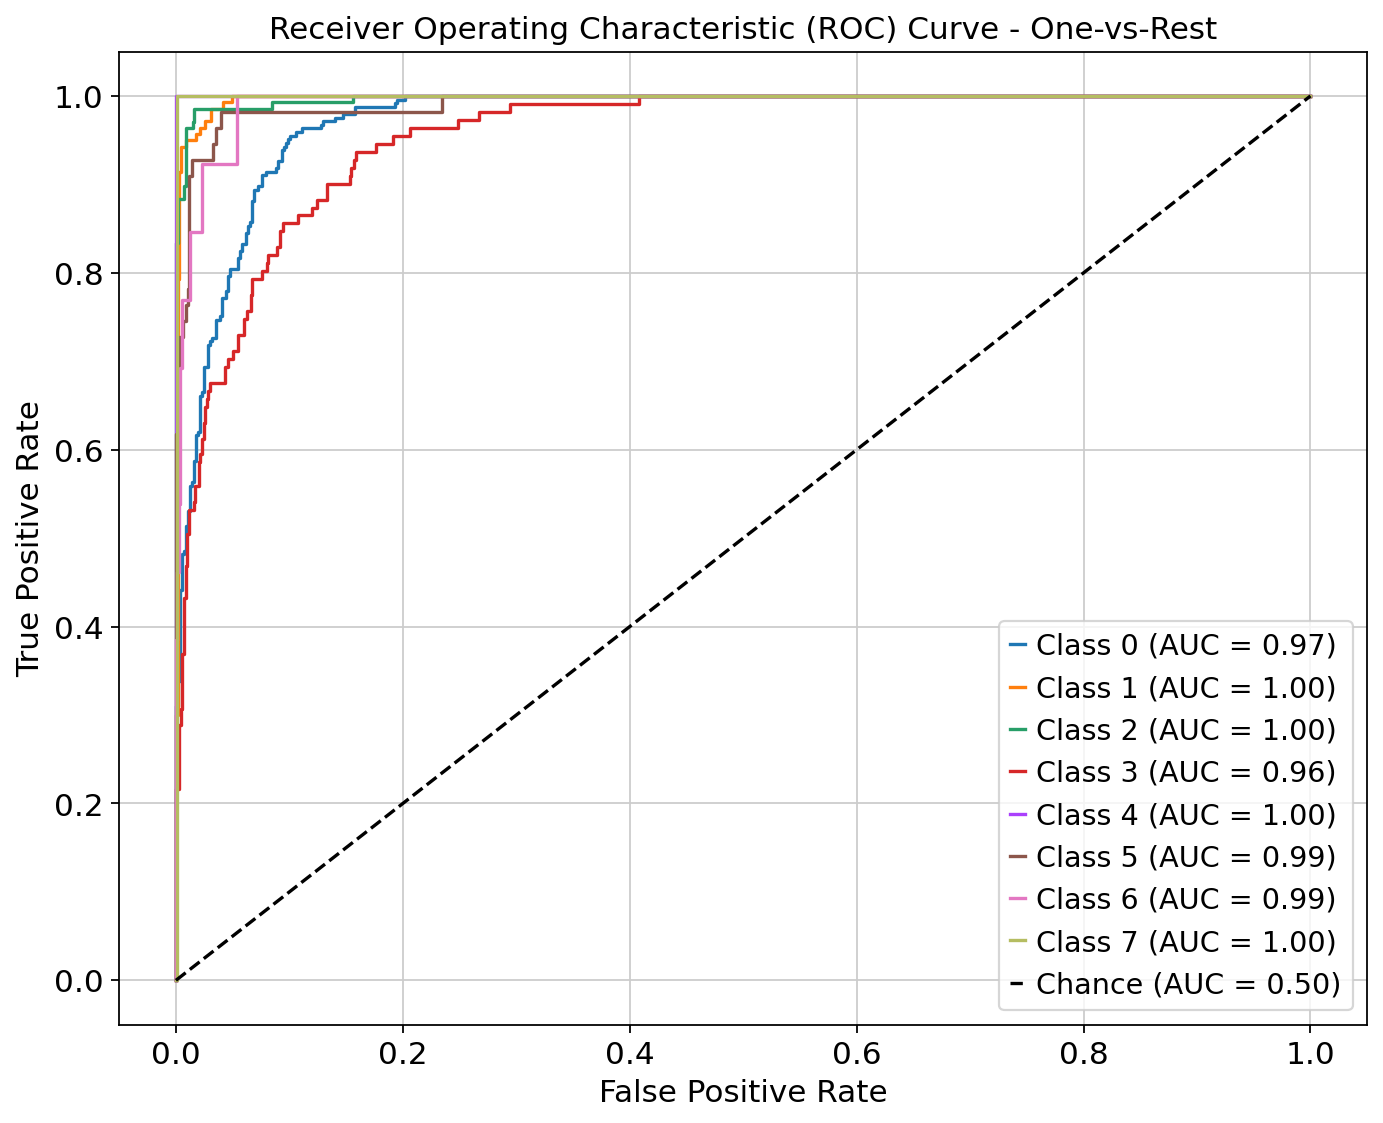


--- Distribution of Prediction Probabilities by True Class ---


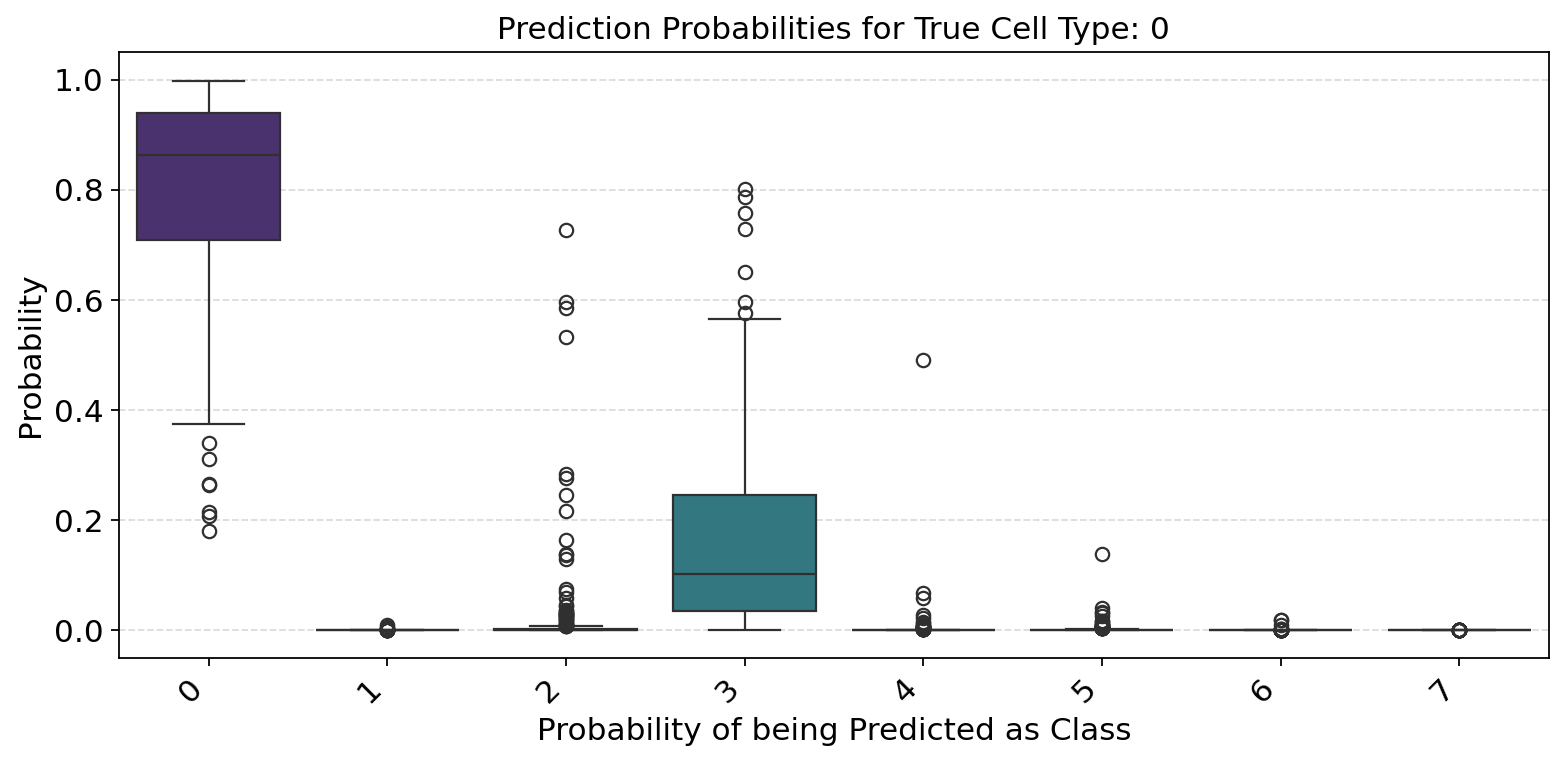

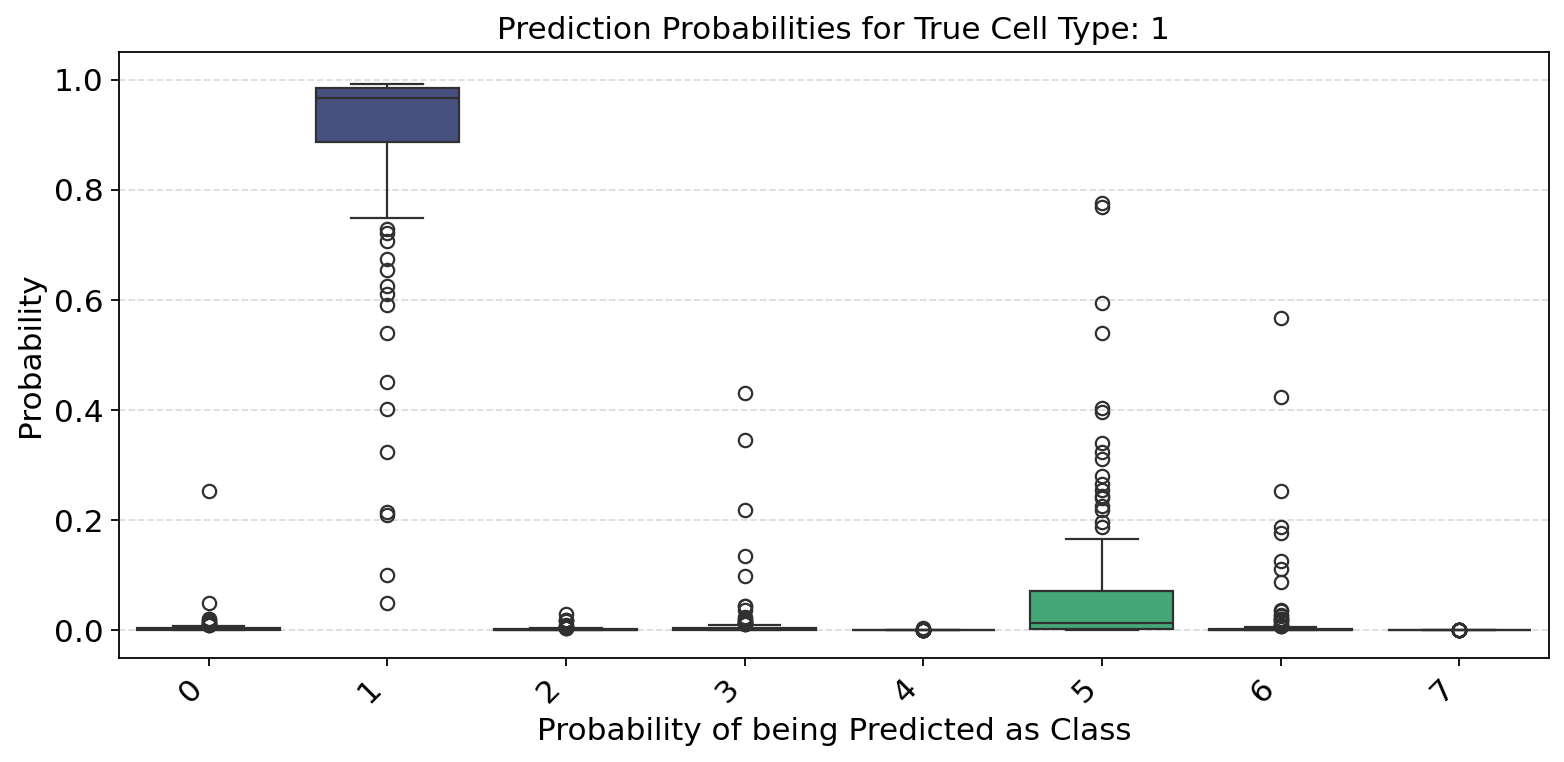

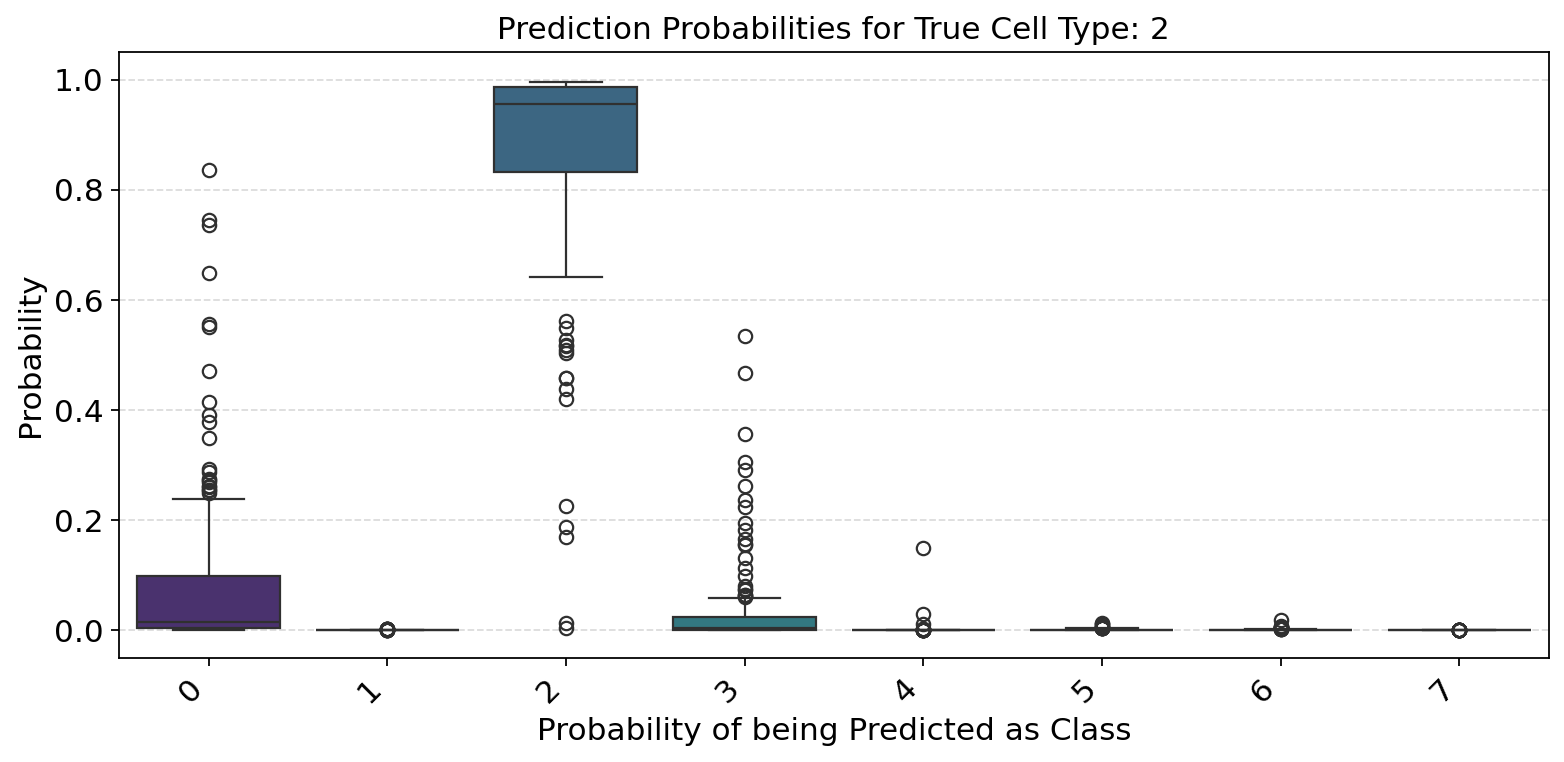

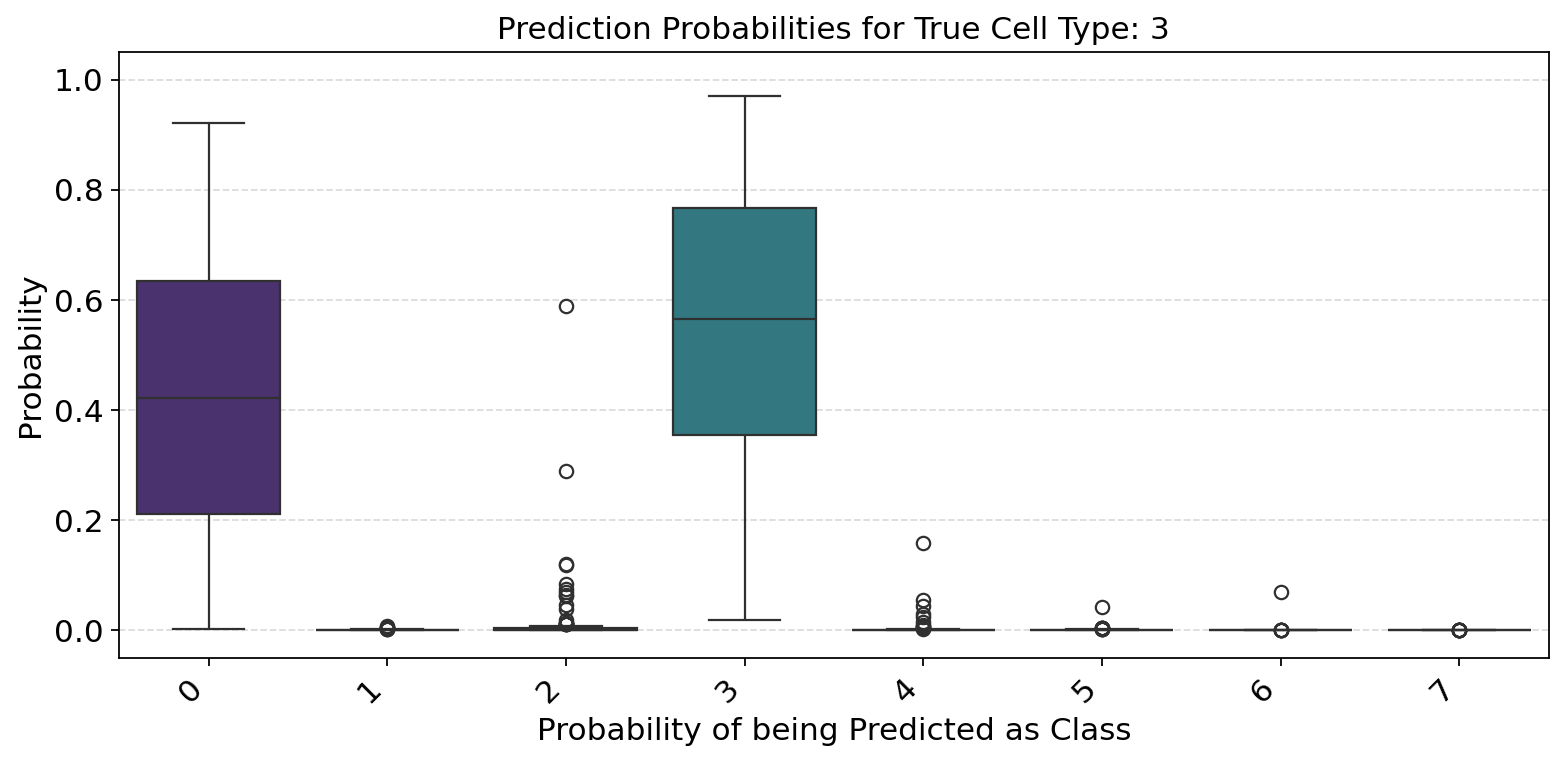

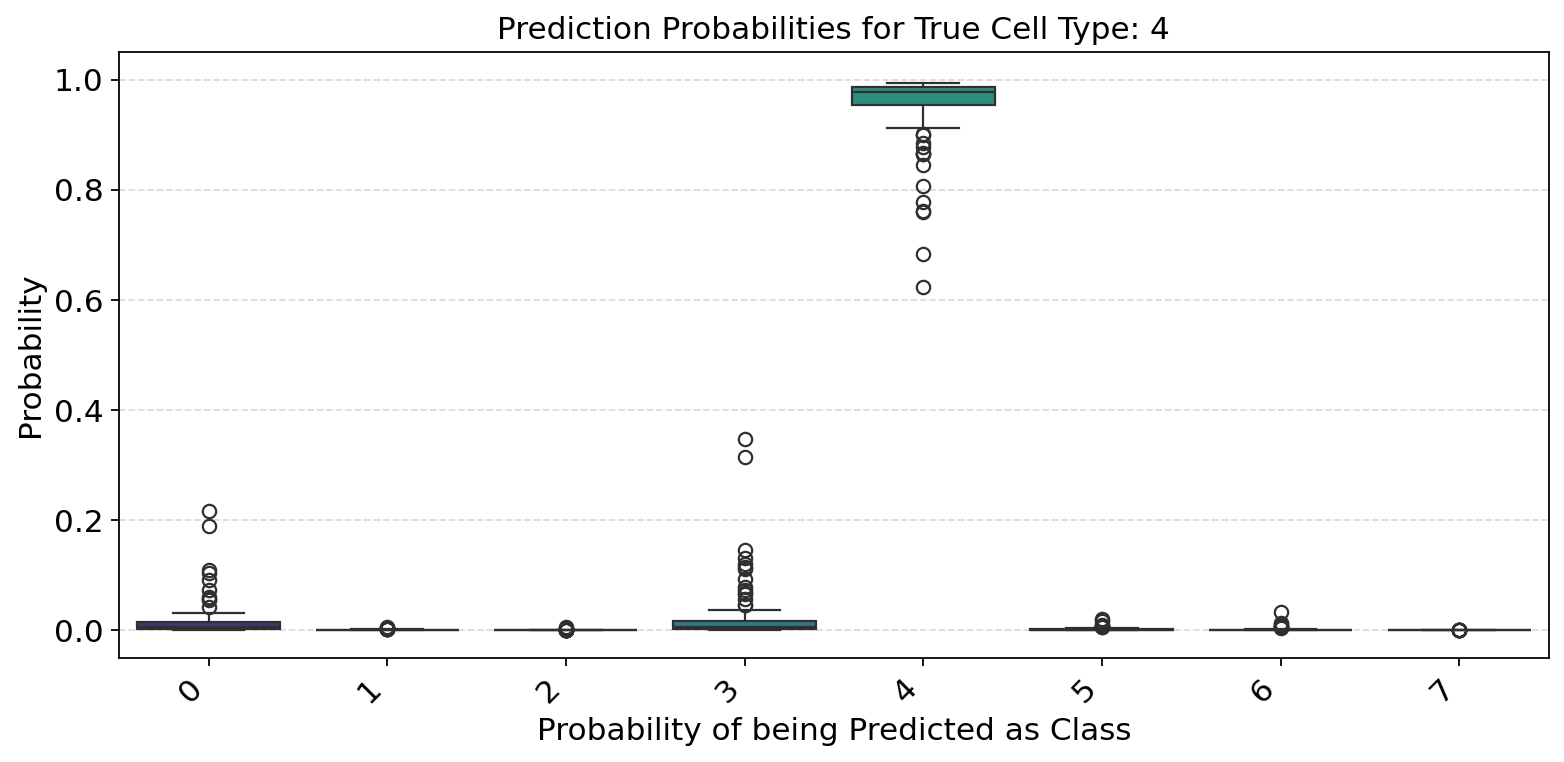

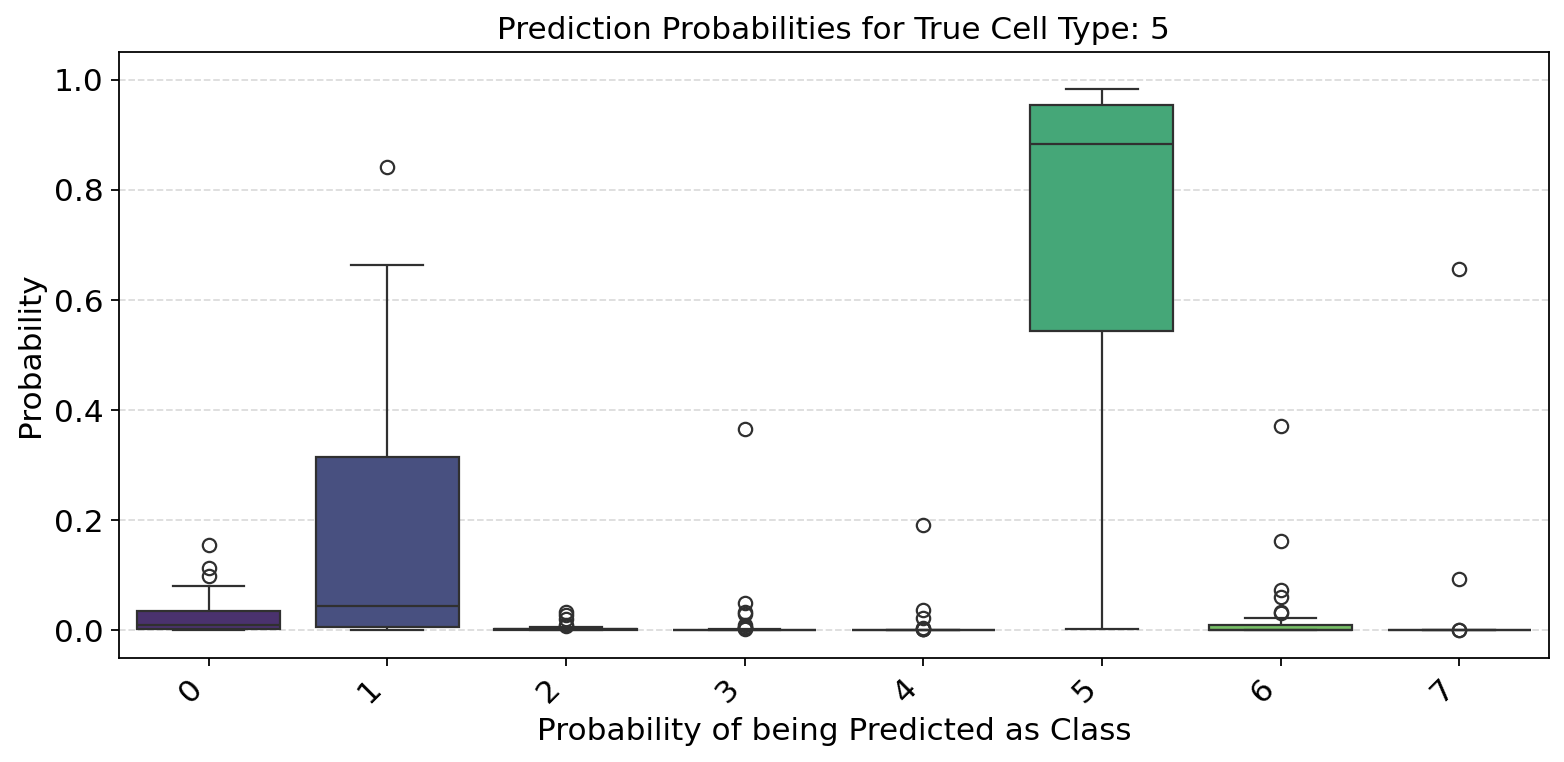

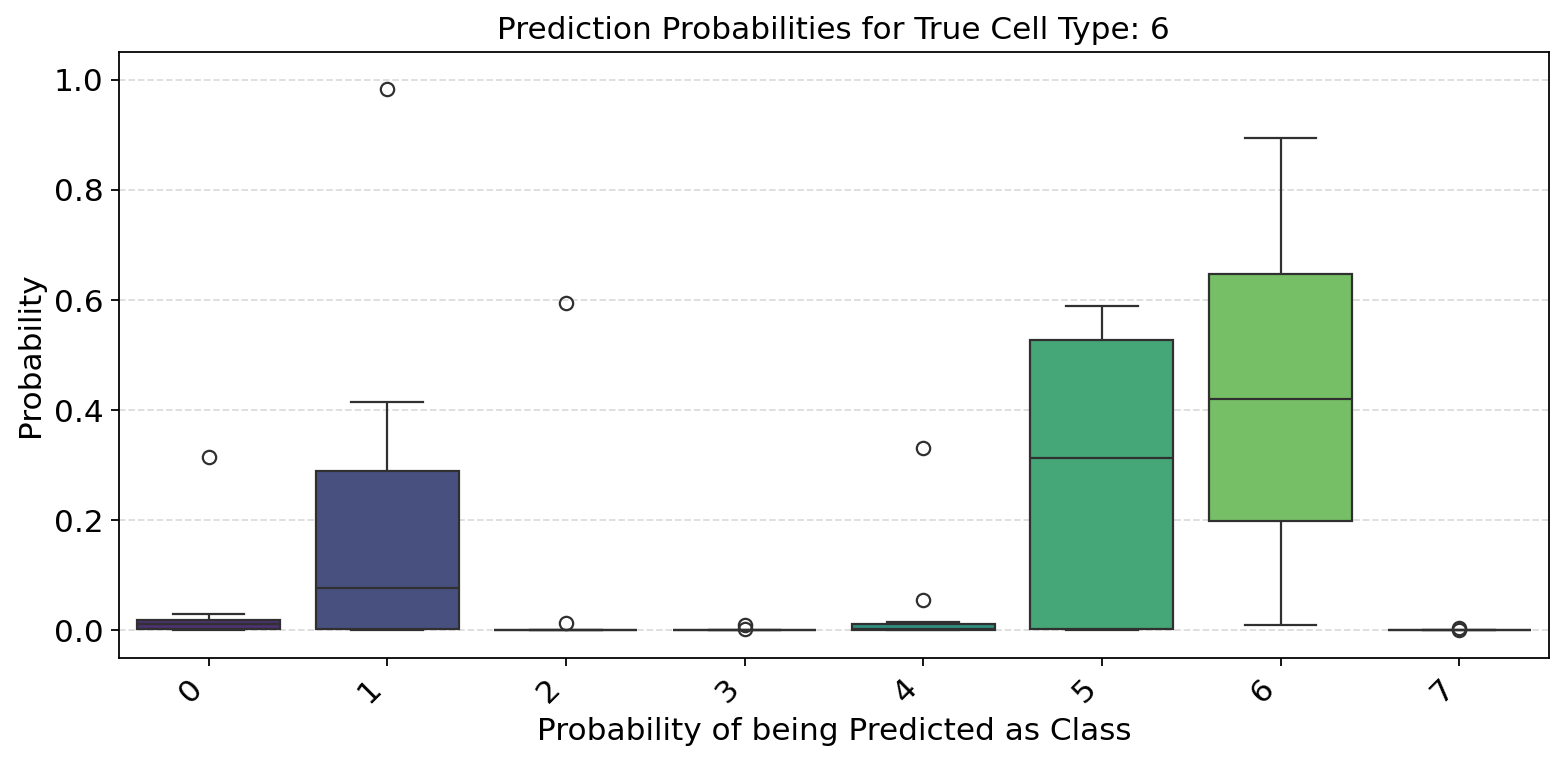

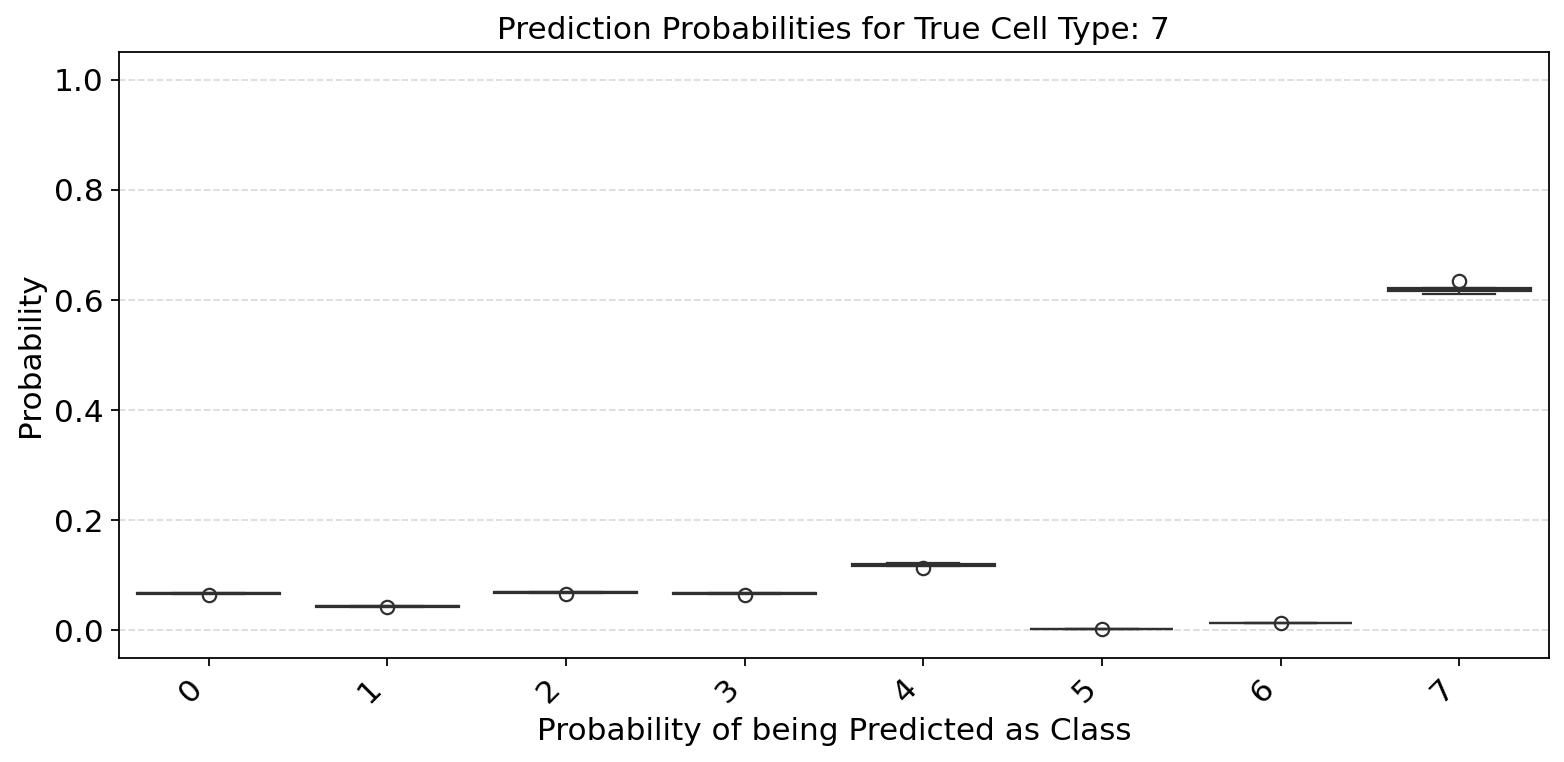


--- Plotting UMAP: True vs Predicted Labels ---


/tmp/ipykernel_4305/3980061807.py:356: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98])


<Figure size 960x480 with 0 Axes>

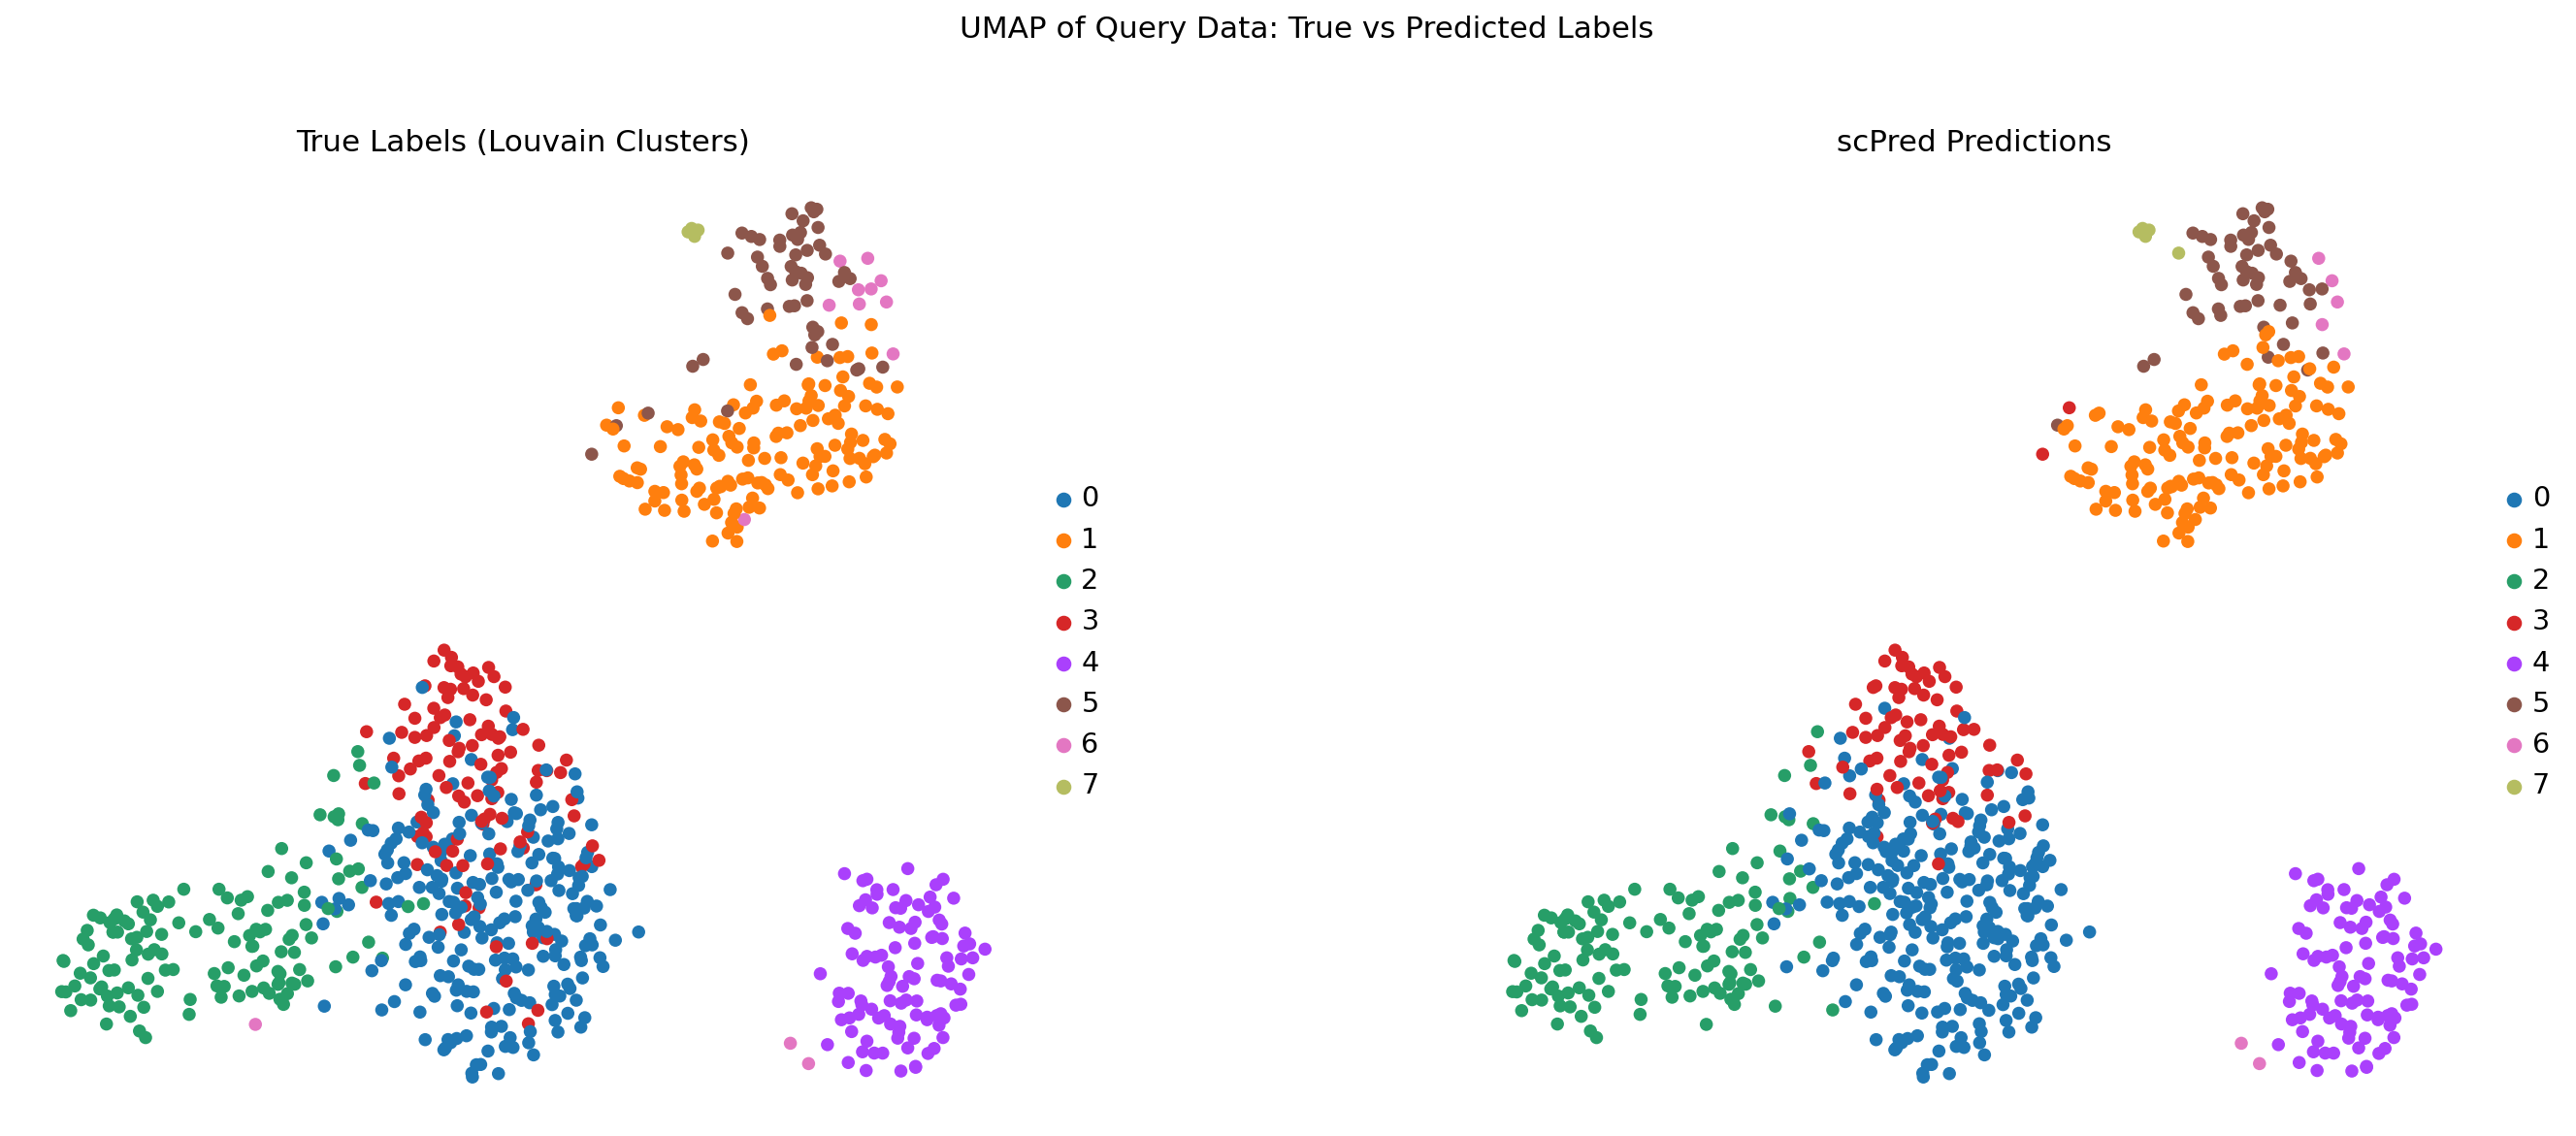


--- Plotting Misclassified Cells UMAP ---


<Figure size 640x480 with 0 Axes>

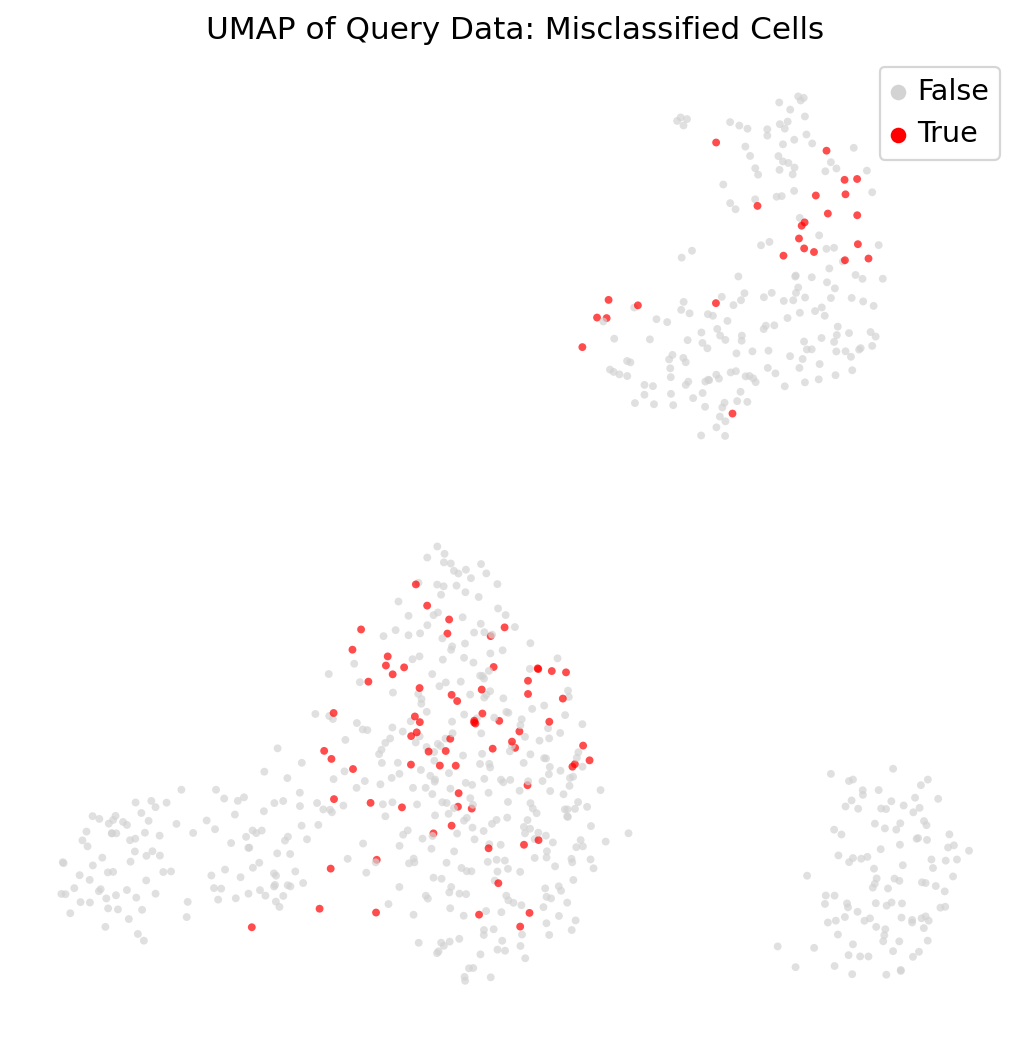


--- Plotting UMAP by Prediction Confidence ---


<Figure size 640x480 with 0 Axes>

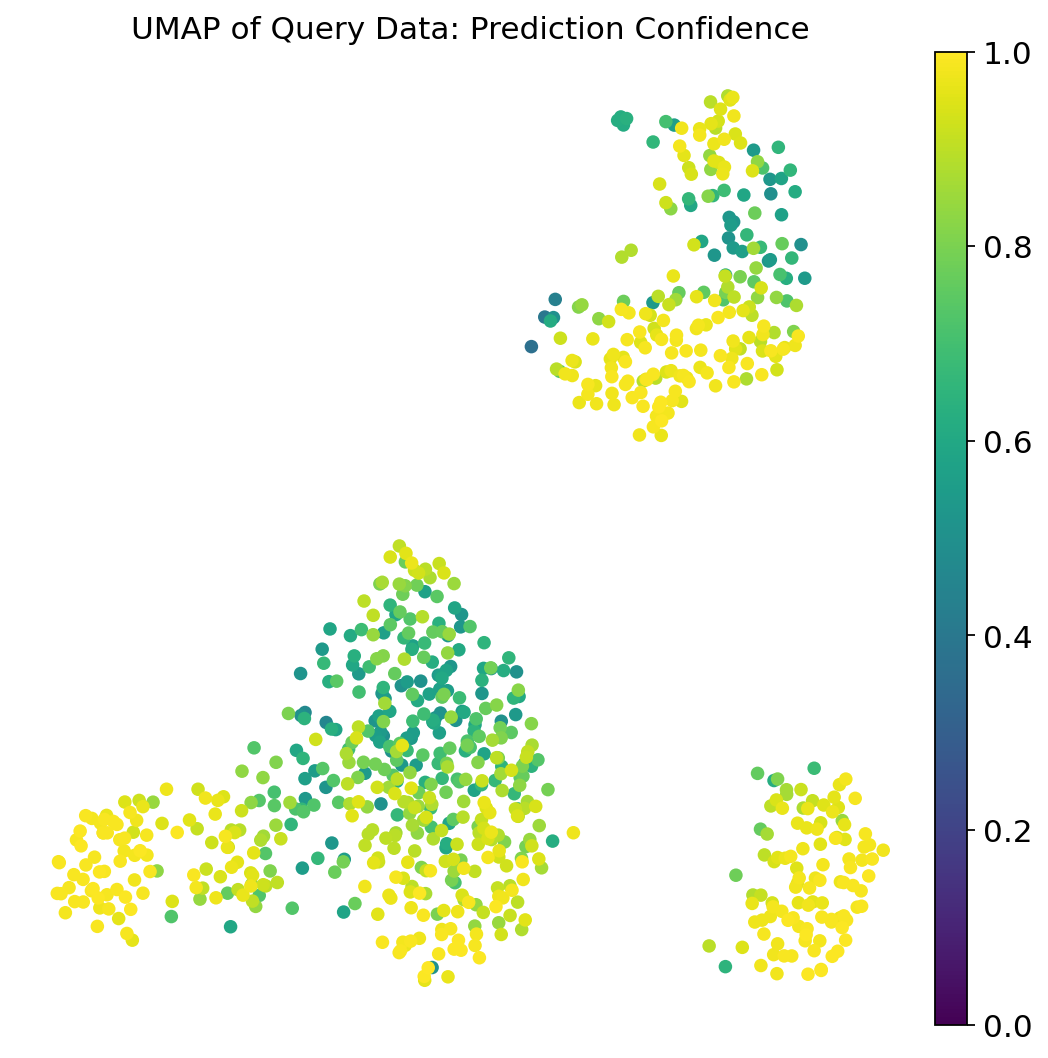


--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import pickle # For saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns
import random # For setting Python's random seed

# Make sure you have these installed: pip install scikit-learn scikit-misc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelBinarizer # ADDED: Import LabelBinarizer for ROC plotting

# Adjust the path to import your scpred_py_final package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_final as per context
from scpred_py_final import _analysis_utils # Assuming _analysis_utils is part of the package


print("--- Setting up environment for reproducibility and file management ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


# --- 1. Data Loading and Initial Annotation ---
print("\n--- Step 1: Loading and Annotating Data ---")
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

print(f"Initial raw AnnData object shape: {adata.shape}")
print(f"Initial raw AnnData .obs keys: {adata.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata.var.keys().tolist()}\n")


# Generate 'cell_type' labels using a temporary preprocessing pipeline
# This prepares the `adata` object with raw counts and the `cell_type` column
print("Generating temporary cell type labels via Louvain clustering...")
temp_adata_for_labels = adata.copy()
sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
sc.pp.log1p(temp_adata_for_labels)
sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE) # Added random_state
sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE) # Added random_state
sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type') # Added random_state

# Assign the generated cell_type labels back to the original raw adata object
adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category') # Ensure category type

print(f"Full dataset (raw counts + Louvain labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())


# --- 2. Train-Test Split (Stratified) ---
# We split the raw data (with labels) into reference and query sets.
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata.n_obs)

ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=RANDOM_STATE, # Ensuring split is reproducible
    stratify=adata.obs['cell_type'] # CRITICAL for balanced classes
)

# These AnnData objects contain raw counts and cell_type labels.
# The ScPredModel will handle their internal preprocessing.
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw.obs['cell_type'].value_counts())
print("\nQuery cell type distribution:\n", query_adata_raw.obs['cell_type'].value_counts())


# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())


# --- 3. Training the scPred Model ---
# The ScPredModel will now handle all preprocessing (normalization, log1p, HVG, scaling, PCA) internally.
print("\n--- Step 3: Training scPred Model ---")
scpred_model = ScPredModel()

# Train the model on the raw reference data with optimal parameters
scpred_model.train(
    ref_adata=ref_adata_raw, # Pass the raw reference data
    cell_type_key='cell_type',
    n_components=30,
    hvg_n_top_genes=1000, # Optimal: Select top 1000 HVGs
    hvg_flavor='seurat',  # Using 'seurat' flavor for HVG selection
    svm_kernel='rbf',     # Optimal: RBF kernel
    svm_c=1.0,            # Optimal: C=1.0
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight='balanced' # Optimal: Balanced class weight
)

print("\nModel Trained!")
print(f"Scaler: {scpred_model.scaler_}")
print(f"PCA Model: {scpred_model.pca_model_}")
print(f"Classifier: {scpred_model.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model.reference_hvg_genes_)} genes")

# Save the trained ScPredModel object using its new method
model_path = os.path.join(MODELS_DIR, 'scpred_model_pbmc3k.pkl')
scpred_model.save(model_path)

# Save the preprocessed reference data (now accessible via scpred_model.ref_adata_processed_)
if scpred_model.ref_adata_processed_ is not None:
    preprocessed_ref_path = os.path.join(PREPROCESSED_DATA_DIR, 'pbmc3k_ref_preprocessed.h5ad')
    scpred_model.ref_adata_processed_.write(preprocessed_ref_path)
    print(f"Preprocessed reference data saved to: {preprocessed_ref_path}")
else:
    print("Warning: scpred_model.ref_adata_processed_ is None. Preprocessed reference data not saved.")


# --- 4. Predicting with the scPred Model ---
# The model will use its saved preprocessing steps and trained classifier to predict.
print("\n--- Step 4: Predicting on Query Data ---")
# Use the optimal prediction threshold (e.g., 0.8 as in comparative analysis)
query_adata_pred = scpred_model.predict(query_adata_raw, threshold=0.0) # Pass the raw query data

print("\nQuery Data with Predictions (first 5 rows):")
print(query_adata_pred.obs[['cell_type', 'scpred_prediction']].head())
print(f"\nQuery data .obs keys after prediction: {query_adata_pred.obs.keys().tolist()}")
print(f"Query data .obsm keys after prediction: {list(query_adata_pred.obsm.keys())}")
print("\nPredicted label distribution (including 'unassigned'):\n", query_adata_pred.obs['scpred_prediction'].value_counts(dropna=False))


# Save the preprocessed query data with predictions
preprocessed_query_path = os.path.join(PREPROCESSED_DATA_DIR, 'pbmc3k_query_pred_preprocessed.h5ad')
query_adata_pred.write(preprocessed_query_path)
print(f"Preprocessed query data with predictions saved to: {preprocessed_query_path}")


# --- 5. Evaluating Predictions (using _analysis_utils for metrics) ---
true_labels = query_adata_pred.obs['cell_type']
predicted_labels = query_adata_pred.obs['scpred_prediction']

# Extract prediction probabilities (columns starting with 'scpred_prob_')
# and ensure they are ordered according to the classifier's classes
pred_prob_cols = [f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]
y_pred_probs_df = None
if all(col in query_adata_pred.obs.columns for col in pred_prob_cols):
    y_pred_probs_df = query_adata_pred.obs[pred_prob_cols].copy()
    # REMOVED: y_pred_probs_df.columns = [col.replace('scpred_prob_', '') for col in y_pred_probs_df.columns]
else:
    print("Warning: Not all scpred_prob_X columns found. ROC AUC calculation might be affected.")


# Use the helper function for metrics
metrics_results = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels,
    predicted_labels=predicted_labels,
    classifier_classes=scpred_model.classifier_.classes_, # Pass classifier classes for robust reporting
    y_pred_probs=y_pred_probs_df
)


# --- 6. Visualizing Results (plotting code directly in notebook) ---
print("\n--- Step 6: Visualizing Results ---")

# Ensure UMAP embedding is computed on the projected PCs if not already present
if 'X_scpred_pca' in query_adata_pred.obsm and 'X_umap' not in query_adata_pred.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
    sc.pp.neighbors(query_adata_pred, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE) # Added random_state
    sc.tl.umap(query_adata_pred, random_state=RANDOM_STATE) # Added random_state
    print(f"Query data .obsm keys after UMAP: {list(query_adata_pred.obsm.keys())}")
elif 'X_umap' not in query_adata_pred.obsm:
    print("X_scpred_pca or X_umap not found in .obsm. UMAP plots might not be generated.")


# Plot 1: Confusion Matrix
print("\n--- Confusion Matrix ---")
# Ensure labels are string type consistently
true_labels_str = true_labels.astype(str)
predicted_labels_str = predicted_labels.astype(str)

# Filter out NaNs from predictions before confusion matrix calculation
# This ensures only cells with actual predictions (assigned or unassigned) are considered
valid_cm_mask = predicted_labels_str.notna()
filtered_true_labels_cm = true_labels_str[valid_cm_mask]
filtered_predicted_labels_cm = predicted_labels_str[valid_cm_mask]

# Ensure all unique labels (true and predicted, including 'unassigned') are used for CM labels
cm_labels_str = sorted(list(set(filtered_true_labels_cm.unique()) | set(filtered_predicted_labels_cm.unique())))

# If 'unassigned' is in the predicted labels, ensure it's at the end for consistent visualization
if 'unassigned' in cm_labels_str:
    cm_labels_str.remove('unassigned')
    cm_labels_str.append('unassigned')

# Calculate confusion matrix only on valid predictions
cm = confusion_matrix(filtered_true_labels_cm, filtered_predicted_labels_cm, labels=cm_labels_str)
cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
plt.title('Confusion Matrix (True vs. Predicted Labels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Plot 2: Per-Class ROC AUC (One-vs-Rest)
print("\n--- Per-Class ROC AUC (One-vs-Rest) ---")
# ROC AUC is only meaningful if classifier.predict_proba is available
if hasattr(scpred_model.classifier_, 'predict_proba') and y_pred_probs_df is not None:
    # Filter for valid predictions (not NaN) and not 'unassigned' for ROC calculation
    # ROC AUC is typically calculated on binary classification (assigned vs. not assigned, for each class)
    # So we need to filter out 'unassigned' from the true labels as well for this specific plot setup
    roc_plot_mask = (predicted_labels_str.notna()) & (predicted_labels_str != 'unassigned')
    
    true_labels_for_roc = true_labels_str[roc_plot_mask].copy()
    y_scores_for_roc = y_pred_probs_df.loc[roc_plot_mask].copy() # y_pred_probs_df already has class names as cols

    if not true_labels_for_roc.empty and not y_scores_for_roc.empty:
        classes = scpred_model.classifier_.classes_
        
        # Binarize true labels for ROC calculation
        label_binarizer = LabelBinarizer()
        # Fit on all original classifier classes to ensure consistent order
        label_binarizer.fit([str(c) for c in classes]) 
        y_true_binary = label_binarizer.transform(true_labels_for_roc)
        
        # Ensure y_scores_for_roc columns match the order of classes in label_binarizer
        # The columns of y_scores_for_roc are now 'scpred_prob_0', 'scpred_prob_1', etc.
        # We need to extract the values for the specific class.
        y_scores_array = y_scores_for_roc[[f"scpred_prob_{str(c)}" for c in label_binarizer.classes_]].values


        plt.figure(figsize=(10, 8))
        for i, class_label in enumerate(label_binarizer.classes_):
            # Check if class has both 0 and 1 in true labels for ROC calculation
            if y_true_binary.shape[1] > i and len(np.unique(y_true_binary[:, i])) > 1:
                fpr, tpr, _ = roc_curve(y_true_binary[:, i], y_scores_array[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')
            else:
                print(f"Skipping ROC plot for Class {class_label}: Not enough unique true labels in filtered set.")

        plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    else:
        print("Not enough valid data to generate ROC plots after filtering for NaN/unassigned values.")
else:
    print("Classifier does not support `predict_proba` or probabilities not available, cannot compute ROC AUC.")


# Plot 3: Distribution of Prediction Probabilities by True Class
print("\n--- Distribution of Prediction Probabilities by True Class ---")
if hasattr(scpred_model.classifier_, 'predict_proba') and y_pred_probs_df is not None:
    # Filter out 'unassigned' cells from the true labels for this plot
    # and also filter out any NaNs in the probabilities
    prob_plot_mask = (predicted_labels_str.notna()) & (predicted_labels_str != 'unassigned')
    
    prob_df_for_plot = y_pred_probs_df.loc[prob_plot_mask].copy()
    prob_df_for_plot['true_cell_type'] = true_labels_str[prob_plot_mask].copy()

    if not prob_df_for_plot.empty:
        # Melt the DataFrame for easier plotting with seaborn
        # Now, value_vars should also use the 'scpred_prob_' prefix
        prob_melted = prob_df_for_plot.melt(
            id_vars='true_cell_type',
            value_vars=[f"scpred_prob_{str(c)}" for c in scpred_model.classifier_.classes_], # Use prefixed class names
            var_name='predicted_class_prob_of',
            value_name='probability'
        )

        # This line is supposed to remove the prefix
        prob_melted['predicted_class_prob_of'] = prob_melted['predicted_class_prob_of'].str.replace('scpred_prob_', '')

        # Plotting loop for each true cell type
        for true_type in sorted(prob_melted['true_cell_type'].unique()):
            plt.figure(figsize=(10, 5))
            subset_df = prob_melted[prob_melted['true_cell_type'] == true_type]
            if not subset_df.empty:
                sns.boxplot(
                    data=subset_df,
                    x='predicted_class_prob_of',
                    y='probability',
                    hue='predicted_class_prob_of',
                    palette='viridis',
                    legend=False
                )
                plt.title(f'Prediction Probabilities for True Cell Type: {true_type}')
                plt.xlabel('Probability of being Predicted as Class')
                plt.ylabel('Probability')
                plt.ylim(-0.05, 1.05) # Consistent y-axis limits
                plt.grid(axis='y', linestyle='--', alpha=0.7)
                plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
                plt.tight_layout()
                plt.show()
            else:
                print(f"Skipping probability distribution plot for True Cell Type {true_type}: No data after filtering.")
    else:
        print("Not enough valid data to generate probability distribution plots after filtering.")
else:
    print("Classifier does not support `predict_proba` or probabilities not available, cannot visualize probability distributions.")


# Plot 4: True vs Predicted Labels UMAP
if 'X_umap' in query_adata_pred.obsm:
    print("\n--- Plotting UMAP: True vs Predicted Labels ---")
    plt.figure(figsize=(12, 6)) # Use figsize here to control the overall figure size
    
    sc.pl.umap(
        query_adata_pred,
        color=['cell_type', 'scpred_prediction'],
        title=['True Labels (Louvain Clusters)', 'scPred Predictions'],
        frameon=False,
        show=False, # Set show=False to control display manually
        ncols=2,
        wspace=0.3 # Adjust horizontal space between subplots
    )
    plt.suptitle('UMAP of Query Data: True vs Predicted Labels', y=1.02, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
else:
    print("Skipping UMAP: True vs Predicted Labels as 'X_umap' is not available in .obsm.")


# Plot 5: Misclassified Cells UMAP
if 'X_umap' in query_adata_pred.obsm:
    print("\n--- Plotting Misclassified Cells UMAP ---")
    # Ensure true_labels_str and predicted_labels_str are available (as they are in notebook scope)
    true_labels_str = query_adata_pred.obs['cell_type'].astype(str)
    predicted_labels_str = query_adata_pred.obs['scpred_prediction'].astype(str)

    # Filter out NaNs from predicted_labels for this plot
    valid_misclassified_mask = predicted_labels_str.notna()
    
    # Create a temporary series for misclassified status on valid cells
    temp_misclassified_series = (true_labels_str[valid_misclassified_mask] != predicted_labels_str[valid_misclassified_mask]).astype(str).astype('category')
    
    # Assign back to adata.obs for plotting, reindexing to original full index
    query_adata_pred.obs['misclassified'] = temp_misclassified_series.reindex(query_adata_pred.obs_names)
    
    misclassified_palette = {'True': 'red', 'False': 'lightgray'}
    
    plt.figure(figsize=(8, 6))
    sc.pl.umap(
        query_adata_pred,
        color='misclassified',
        palette=misclassified_palette,
        size=50,
        alpha=0.7,
        title='UMAP of Query Data: Misclassified Cells',
        frameon=False,
        show=False,
        legend_loc='upper right' # Changed legend location
    )
    plt.show()
else:
    print("Skipping Misclassified Cells UMAP as 'X_umap' is not available in .obsm.")


# Plot 6: UMAP colored by Prediction Confidence
if 'X_umap' in query_adata_pred.obsm and hasattr(scpred_model.classifier_, 'predict_proba'):
    print("\n--- Plotting UMAP by Prediction Confidence ---")
    # Get the probability for the *predicted* class for each cell
    def get_predicted_prob_score(row, classes):
        pred_class = row['scpred_prediction']
        # If 'unassigned', assign 0 confidence for visualization
        if pred_class == 'unassigned' or pd.isna(pred_class):
            return 0.0
        prob_col_name = f'scpred_prob_{pred_class}'
        if prob_col_name in row.index:
            return row[prob_col_name]
        return np.nan # Should not happen with current setup

    prob_cols = [f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]
    
    if not all(col in query_adata_pred.obs.columns for col in prob_cols):
        print("Skipping UMAP by prediction confidence: Required probability columns not found in .obs.")
    else:
        # Create a temporary DataFrame for apply, including scpred_prediction and all prob columns
        temp_obs_for_apply = query_adata_pred.obs[['scpred_prediction'] + prob_cols]
        
        # Apply the function to calculate the predicted_prob_score
        query_adata_pred.obs['predicted_prob_score'] = temp_obs_for_apply.apply(
            lambda row: get_predicted_prob_score(row, scpred_model.classifier_.classes_), axis=1
        )

        plt.figure(figsize=(8, 6))
        sc.pl.umap(
            query_adata_pred,
            color='predicted_prob_score',
            cmap='viridis',
            title='UMAP of Query Data: Prediction Confidence',
            frameon=False,
            vmin=0.0, vmax=1.0,
            show=False
        )
        plt.show()
else:
    print("Skipping UMAP by prediction confidence: 'X_umap' not available or classifier does not support `predict_proba`.")

print("\n--- Analysis Complete ---")
